In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# 0. Definição e Carregamento de todas as bases de dados
# (Certifique-se de que os arquivos .csv estão na mesma pasta do seu notebook)
df_reservas = pd.read_csv('reservas.csv', sep=';')
df_unidades = pd.read_csv('unidades.csv', sep=';')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';')
df_clientes = pd.read_csv('clientes.csv', sep=';')
df_canais = pd.read_csv('canais_venda.csv', sep=';')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';')

In [3]:
# 1. Cruzando reservas, tipos de quarto e unidades para obter o faturamento por reserva e a região
df_p6 = df_reservas.merge(df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']], on='id_tipo_quarto', how='left')
df_p6 = df_p6.merge(df_unidades[['id_unidade', 'regiao', 'nome_unidade']], on='id_unidade', how='left')
df_p6['faturamento'] = df_p6['qtd_diarias'] * df_p6['valor_diaria_base']



In [4]:
# 2. Calculando estatísticas de variabilidade do faturamento por região
resumo_regiao = df_p6.groupby('regiao')['faturamento'].agg(['count', 'mean', 'median', 'std', 'max', 'min']).reset_index()
resumo_regiao.columns = ['Região', 'Qtd Reservas', 'Média', 'Mediana', 'Desvio Padrão', 'Máximo', 'Mínimo']
resumo_regiao = resumo_regiao.sort_values(by='Desvio Padrão', ascending=False)

display(resumo_regiao)



,Região,Qtd Reservas,Média,Mediana,Desvio Padrão,Máximo,Mínimo
3,Serra,584,2555.650685,1960.0,2071.455911,10500.0,-580.0
2,Costa Verde,600,2402.383333,1740.0,1957.413156,10500.0,0.0
1,Capital,845,1880.047337,1260.0,1793.954830,10500.0,0.0
0,Baixada Fluminense,428,1553.014019,840.0,1709.819561,10500.0,-420.0


C:\Users\Robert\AppData\Local\Temp\ipykernel_1292\2116428303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_p6, x='regiao', y='faturamento', palette='Set2')


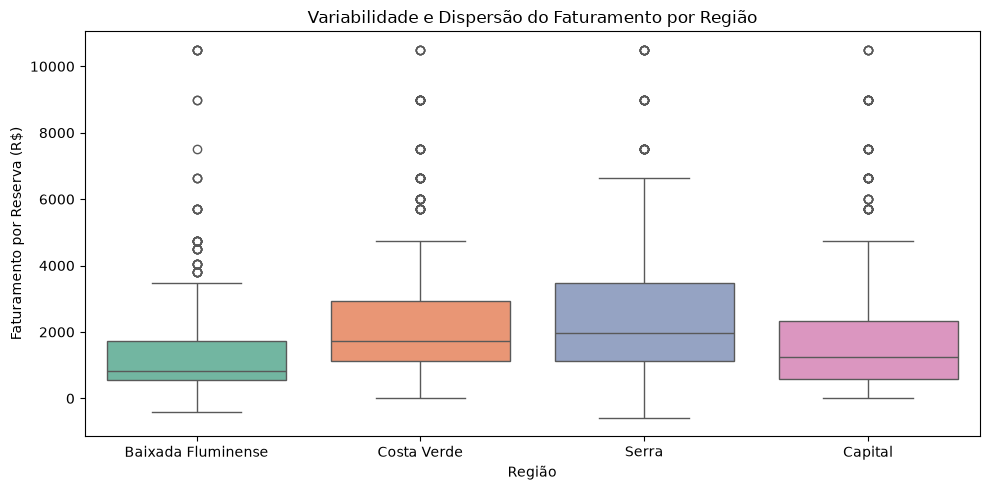

In [5]:
# 3. Visualização Gráfica: Boxplot do Faturamento por Região
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_p6, x='regiao', y='faturamento', palette='Set2')
plt.title('Variabilidade e Dispersão do Faturamento por Região')
plt.xlabel('Região')
plt.ylabel('Faturamento por Reserva (R$)')
plt.tight_layout()
plt.show()

#### Maior Variabilidade (Região Serra): A região Serra lidera tanto o faturamento médio (R$ 2.555,65) quanto a dispersão estatística, registrando o maior desvio padrão (2.071,46). Isso indica uma forte oscilação no perfil das reservas, combinando pacotes de alto valor com transações de menor expressão.

Estabilidade e Volume (Capital e Costa Verde): A Capital concentra o maior volume de reservas (845), mas com uma média menor (R$ 1.880,05). Já a Costa Verde mantém um equilíbrio sólido entre volume (600 reservas) e tíquete médio elevado (R$ 2.402,38).

Alerta Contábil (Valores Negativos): A presença de valores mínimos negativos na Serra (-R$ 580,00) e na Baixada Fluminense (-R$ 420,00) aponta a existência de estornos, cancelamentos mal lançados ou abatimentos na base de dados que precisam ser auditados pelo time financeiro.

O que isso indica para a gestão comercial:
A alta variabilidade na Serra e na Baixada mostra que a estratégia de vendas está descentralizada ou sofre com distorções operacionais (como cancelamentos e estornos frequentes). A diretoria comercial precisa padronizar os pacotes de preços nessas regiões e auditar urgentemente os lançamentos negativos para evitar distorções de receita no fechamento do mês.
